# Exercise 1: Explore Filter Parameters

In [1]:
import matplotlib.pyplot as plt
#import seaborn as sns
import pickle
import numpy as np
import sys
import os
os.chdir(r'C:\Users\vitto\OneDrive\Desktop\MyProject')
sys.path.append(os.path.abspath("code"))
print(os.getcwd())
import lfp_functions as lf
    

C:\Users\vitto\OneDrive\Desktop\MyProject


In [2]:
with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
print(f'Loaded {len(lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')

Loaded 600.133 seconds of LFP, sampled at 1000.0 Hz


Text(0, 0.5, 'voltage (mV)')

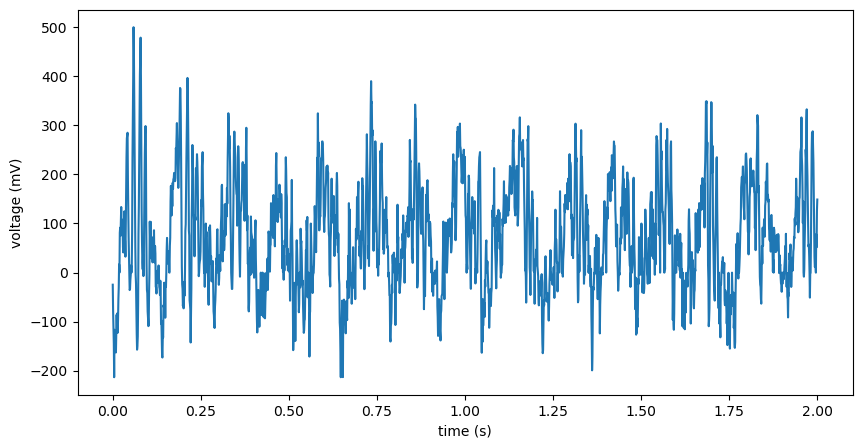

In [3]:
plt.figure(figsize=(10,5))
plt.plot(np.linspace(0,2,2000),lfp[:2000])
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')

In [4]:
lfp_short = lfp[0:int(2 * sampling_rate)]
time = np.arange(len(lfp_short)) / sampling_rate

In [5]:
filtered_lfp_wide   = lf.bandpass_filter(lfp_short, 4,  12, sampling_rate=sampling_rate, filter_order=4)
filtered_lfp_narrow = lf.bandpass_filter(lfp_short, 7,   9, sampling_rate=sampling_rate, filter_order=4)
filtered_lfp_high   = lf.bandpass_filter(lfp_short, 30, 80, sampling_rate=sampling_rate, filter_order=4)

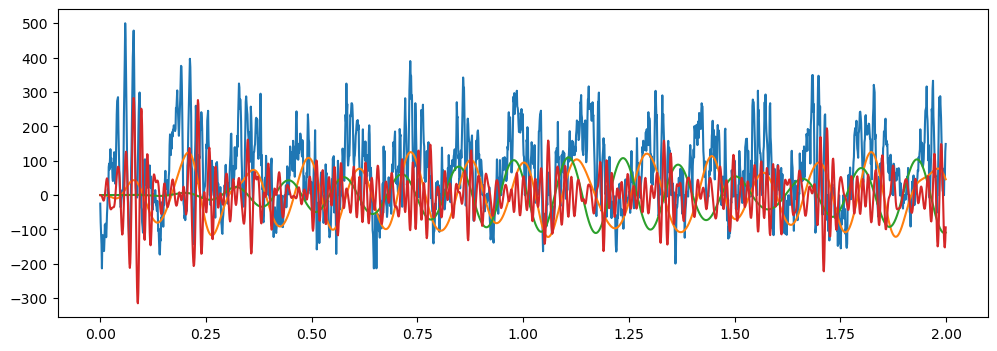

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(time, lfp_short)
plt.plot(time, filtered_lfp_wide)
plt.plot(time, filtered_lfp_narrow)
plt.plot(time, filtered_lfp_high)
plt.show()

In [7]:
filtered_lfp_ord2 = lf.bandpass_filter(lfp_short, 4, 12, sampling_rate=sampling_rate, filter_order=2)
filtered_lfp_ord8 = lf.bandpass_filter(lfp_short, 4, 12, sampling_rate=sampling_rate, filter_order=8)


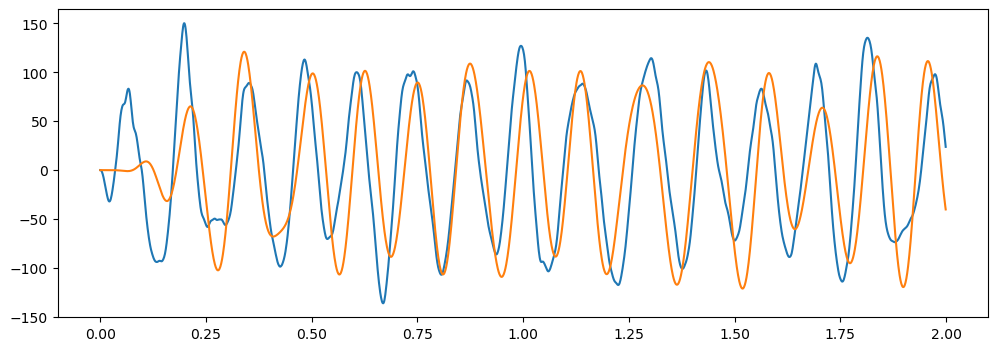

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(time, filtered_lfp_ord2)
plt.plot(time, filtered_lfp_ord8)
plt.show()

In [9]:
%timeit lf.bandpass_filter(lfp_short, 4, 12, sampling_rate=sampling_rate, filter_order=2)
%timeit lf.bandpass_filter(lfp_short, 4, 12, sampling_rate=sampling_rate, filter_order=8)

1.75 ms ± 346 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
4.06 ms ± 428 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
